# THỰC HÀNH 03: PHÁT HIỆN ĐỐI TƯỢNG (OBJECT DETECTION) 

## Thông tin chung

Bài thực hành thuộc môn **Thị Giác Máy Tính Nâng Cao** (*Advanced Computer Vision - K35 - HCMUS*).

- Thành viên nhóm:
  - Nguyễn Trọng Hiếu – 25C11042 (Nhóm trưởng)
  - Trương Lê Bảo Trân – 25C11071
- Giảng viên hướng dẫn: ThS. Nguyễn Mạnh Hùng

## Mục tiêu

- Tìm hiểu mô hình Faster R-CNN.
- Huấn luyện mô hình trên tập dữ liệu Safety Helmet.
- Đánh giá hiệu năng mô hình.
- Thực hiện suy luận trên dữ liệu kiểm thử.


Trong bài thực hành này sử dụng Faster R-CNN để nhận diện mũ bảo hộ lao động trên tập dữ liệu Safety Helmet Dataset.

## Nguồn dữ liệu

Bộ dữ liệu được sử dụng trong bài thực hành là **Safety Helmet Dataset**, được công bố trên nền tảng Roboflow Universe. Bộ dữ liệu bao gồm các ảnh chứa người lao động trong môi trường xây dựng cùng với các nhãn đối tượng Helmet, Head và Person phục vụ cho bài toán phát hiện đối tượng (Object Detection).

Nguồn dữ liệu gốc được truy cập tại:

https://universe.roboflow.com/augmented-startups/safety-helmet-dataset-uvh1t


### 1. Kiểm tra môi trường

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch:", torch.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
PyTorch: 2.11.0+cu128
GPU: Tesla T4


### 2. Kết nối Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### 3. Cài đặt Faster R-CNN

In [ ]:
# Mô hình Faster R-CNN với backbone ResNet50-FPN được khởi tạo từ trọng số pretrained trên bộ dữ liệu COCO. 
# Sau đó, lớp phân loại cuối cùng được thay thế để phù hợp với bài toán phát hiện ba lớp đối tượng gồm Head, Helmet và Person.
# Khởi tạo mô hình Faster R-CNN

!pip install -q pycocotools torchmetrics

import torchvision

from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn
)

from torchvision.models.detection.faster_rcnn import (
    FastRCNNPredictor
)

print(
    "TorchVision:",
    torchvision.__version__
)

# background + head + helmet + person
num_classes = 4

# Tải mô hình pretrained COCO
model = fasterrcnn_resnet50_fpn(
    weights="DEFAULT"
)

# Thay Classification Head cho bài toán hiện tại
in_features = (
    model.roi_heads
         .box_predictor
         .cls_score
         .in_features
)

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# Đưa mô hình lên GPU
model.to(device)

print("Faster R-CNN ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.8 MB/s eta 0:00:00
TorchVision: 0.26.0+cu128
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 192MB/s]


Faster R-CNN ready


### 4. Tải và chuẩn bị dữ liệu

In [4]:
# Tải bộ dữ liệu Safety Helmet (Dataset được lưu dưới định dạng COCO)
import os

DATASET_DIR = "/content/safety-helmet-dataset.v1i.coco"

if not os.path.exists(DATASET_DIR):
    print("Downloading dataset...")

    !pip install -q gdown

    GDRIVE_LINK = "https://drive.google.com/file/d/1qHouId0FNqHbdBTdrj2kEpQHQT1wpEae/view?usp=sharing"

    !gdown --fuzzy "$GDRIVE_LINK" -O dataset.zip

    !unzip -oq dataset.zip -d /content

    print("Dataset ready!")
else:
    print("Dataset already exists!")

Downloading...
From (original): https://drive.google.com/uc?id=1qHouId0FNqHbdBTdrj2kEpQHQT1wpEae
From (redirected): https://drive.google.com/uc?id=1qHouId0FNqHbdBTdrj2kEpQHQT1wpEae&confirm=t&uuid=421ea6c9-c141-4959-a160-ce31988fa6cb
To: /content/dataset.zip
100% 33.2M/33.2M [00:00<00:00, 39.3MB/s]
Dataset ready!


In [ ]:
# Tạo Dataset cho Faster R-CNN
# Bộ dữ liệu Safety Helmet được sử dụng dưới định dạng COCO. 
# Các annotation được chuyển đổi sang cấu trúc dữ liệu mà Torchvision Faster R-CNN yêu cầu, bao gồm thông tin bounding box, nhãn lớp, diện tích đối tượng và image_id.

from torchvision.datasets import CocoDetection
import torchvision.transforms as T
import torch
import os

class FasterRCNNDataset(CocoDetection):

    def __init__(self, img_folder):

        # Đọc ảnh và annotation COCO
        super().__init__(
            img_folder,
            os.path.join(
                img_folder,
                "_annotations.coco.json"
            )
        )

    def __getitem__(self, idx):

        # Lấy ảnh và annotation tương ứng
        image, annotations = super().__getitem__(idx)

        # Chuyển ảnh sang Tensor
        image = T.ToTensor()(image)

        boxes = []
        labels = []
        area = []
        iscrowd = []

        # Chuyển annotation COCO sang định dạng Faster R-CNN
        for ann in annotations:

            cat_id = ann["category_id"]

            # Loại bỏ class ảo person-head-helmet
            if cat_id == 0:
                continue

            x, y, w, h = ann["bbox"]

            boxes.append([
                x,
                y,
                x + w,
                y + h
            ])

            labels.append(cat_id)

            area.append(
                ann.get("area", w * h)
            )

            iscrowd.append(
                ann.get("iscrowd", 0)
            )

        # Tạo target theo định dạng torchvision Faster R-CNN
        target = {
            "boxes": torch.tensor(
                boxes,
                dtype=torch.float32
            ),
            "labels": torch.tensor(
                labels,
                dtype=torch.int64
            ),
            "area": torch.tensor(
                area,
                dtype=torch.float32
            ),
            "iscrowd": torch.tensor(
                iscrowd,
                dtype=torch.int64
            ),
            "image_id": torch.tensor(
                [self.ids[idx]]
            )
        }

        return image, target


# Khởi tạo tập Train / Validation / Test
train_dataset = FasterRCNNDataset(
    os.path.join(DATASET_DIR, "train")
)

val_dataset = FasterRCNNDataset(
    os.path.join(DATASET_DIR, "valid")
)

test_dataset = FasterRCNNDataset(
    os.path.join(DATASET_DIR, "test")
)

# Gom dữ liệu thành batch
def collate_fn(batch):

    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]

    return images, targets

# Hiển thị thông tin dataset
print("\n========== DATASET SUMMARY ==========")
print(f"Train images : {len(train_dataset)}")
print(f"Valid images : {len(val_dataset)}")
print(f"Test images  : {len(test_dataset)}")
print(f"Total images : {len(train_dataset)+len(val_dataset)+len(test_dataset)}")

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

========== DATASET SUMMARY ==========
Train images : 761
Valid images : 218
Test images  : 109
Total images : 1088


### 5. Huấn luyện mô hình

In [6]:
# Tạo DataLoader

from torch.utils.data import DataLoader
from tqdm import tqdm
import torch

# =====================
# DATALOADER
# =====================

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

# =====================
# TRAINING CONFIG
# =====================

NUM_EPOCHS = 100
LEARNING_RATE = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

SAVE_PATH = "./helmet_faster_rcnn.pth"

train_losses = []

print("\n========== TRAINING ==========")

# =====================
# TRAINING LOOP
# =====================

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"
    )

    for images, targets in pbar:

        # Chuyển dữ liệu sang GPU
        images = [
            img.to(device)
            for img in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in t.items()
            }
            for t in targets
        ]

        # Forward Pass
        loss_dict = model(
            images,
            targets
        )

        loss = sum(
            loss_dict.values()
        )

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pbar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / len(train_loader)
    )

    train_losses.append(
        epoch_loss
    )

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Loss = {epoch_loss:.4f}"
    )

# =====================
# SAVE MODEL
# =====================

torch.save(
    model.state_dict(),
    SAVE_PATH
)

print("\nTraining completed!")
print(f"Model saved to: {SAVE_PATH}")


========== TRAINING ==========


Epoch 1/100: 100%|██████████| 96/96 [02:42<00:00,  1.69s/it, loss=0.3497]


Epoch [1/100] Loss = 0.4004


Epoch 2/100: 100%|██████████| 96/96 [02:47<00:00,  1.74s/it, loss=0.2412]


Epoch [2/100] Loss = 0.2932


...

Epoch [98/100] Loss = 0.0248


Epoch 99/100: 100%|██████████| 96/96 [02:46<00:00,  1.73s/it, loss=0.0491]


Epoch [99/100] Loss = 0.0235


Epoch 100/100: 100%|██████████| 96/96 [02:46<00:00,  1.74s/it, loss=0.0468]


Epoch [100/100] Loss = 0.0251

Training completed!
Model saved to: ./helmet_faster_rcnn.pth


### 6. Trực quan hóa kết quả huấn luyện

In [7]:
# Đánh giá mô hình trên tập Validation

from torch.utils.data import DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm
import torch

# =====================
# VALIDATION DATALOADER
# =====================

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

# =====================
# LOAD BEST MODEL
# =====================

model.load_state_dict(
    torch.load(
        SAVE_PATH,
        map_location=device
    )
)

model.to(device)
model.eval()

# =====================
# mAP METRIC
# =====================

metric = MeanAveragePrecision(
    iou_type="bbox"
)

# =====================
# VALIDATION LOOP
# =====================

with torch.no_grad():

    for images, targets in tqdm(val_loader):

        images = [
            img.to(device)
            for img in images
        ]

        outputs = model(images)

        # Chuyển prediction sang định dạng TorchMetrics
        preds = []

        for out in outputs:

            preds.append({
                "boxes": out["boxes"].cpu(),
                "scores": out["scores"].cpu(),
                "labels": out["labels"].cpu()
            })

        # Chuyển ground truth sang định dạng TorchMetrics
        gts = []

        for target in targets:

            gts.append({
                "boxes": target["boxes"].cpu(),
                "labels": target["labels"].cpu()
            })

        metric.update(
            preds,
            gts
        )

# =====================
# COMPUTE METRICS
# =====================

results = metric.compute()

mar100 = results["mar_100"].item()
map50    = results["map_50"].item()
map5095  = results["map"].item()

# =====================
# DISPLAY RESULTS
# =====================

print("\n========== VALIDATION RESULTS ==========")
print(f"mAR@100   : {mar100:.4f}")
print(f"mAP50     : {map50:.4f}")
print(f"mAP50-95  : {map5095:.4f}")

100%|██████████| 55/55 [00:21<00:00,  2.54it/s]


========== VALIDATION RESULTS ==========
mAR@100   : 0.4589
mAP50     : 0.7595
mAP50-95  : 0.3867


Kết quả đánh giá trên tập Validation cho thấy mô hình Faster R-CNN đạt mAP@50 = 0.7595 và mAP@50:95 = 0.3867. Điều này cho thấy mô hình có khả năng phát hiện và định vị các đối tượng trong bộ dữ liệu ở mức tương đối tốt. Giá trị mAR@100 đạt 0.4589 cho thấy mô hình vẫn còn bỏ sót một số đối tượng, đặc biệt trong các trường hợp đối tượng có kích thước nhỏ hoặc bị che khuất. Nhìn chung, mô hình đã học được các đặc trưng cần thiết của dữ liệu và đạt hiệu năng đủ tốt để tiếp tục đánh giá trên tập Test.

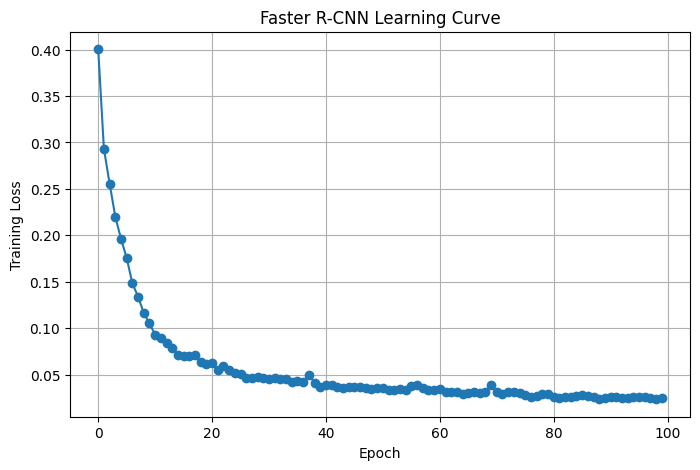

In [ ]:
# Learning Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    marker="o"
)

plt.title(
    "Faster R-CNN Learning Curve"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.grid(True)

plt.show()

Giá trị Training Loss giảm nhanh trong các epoch đầu và tiếp tục giảm dần ở các epoch sau, cho thấy mô hình Faster R-CNN học được đặc trưng của dữ liệu và quá trình huấn luyện diễn ra ổn định. Đường cong hội tụ tương đối tốt, không xuất hiện hiện tượng dao động mạnh.

### 7. Đánh giá mô hình tốt nhất trên tập Test

In [11]:
from torch.utils.data import DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm
import torch

# =====================
# TEST DATALOADER
# =====================

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

# =====================
# LOAD BEST MODEL
# =====================

model.load_state_dict(
    torch.load(
        SAVE_PATH,
        map_location=device
    )
)

model.to(device)
model.eval()

# =====================
# EVALUATION
# =====================

metric = MeanAveragePrecision(
    iou_type="bbox"
)

with torch.no_grad():

    for images, targets in tqdm(
        test_loader,
        desc="Testing"
    ):

        images = [
            img.to(device)
            for img in images
        ]

        outputs = model(images)

        predictions = []

        for output in outputs:

            predictions.append({
                "boxes": output["boxes"].cpu(),
                "scores": output["scores"].cpu(),
                "labels": output["labels"].cpu()
            })

        ground_truths = []

        for target in targets:

            ground_truths.append({
                "boxes": target["boxes"].cpu(),
                "labels": target["labels"].cpu()
            })

        metric.update(
            predictions,
            ground_truths
        )

results = metric.compute()

recall    = results["mar_100"].item()
map50     = results["map_50"].item()
map5095   = results["map"].item()

print("\n========== TEST RESULTS ==========")
print(f"Recall    : {recall:.4f}")
print(f"mAP50     : {map50:.4f}")
print(f"mAP50-95  : {map5095:.4f}")

Testing: 100%|██████████| 28/28 [00:10<00:00,  2.61it/s]



========== TEST RESULTS ==========
Recall    : 0.4938
mAP50     : 0.8059
mAP50-95  : 0.4200


Kết quả trên tập Test cho thấy mô hình Faster R-CNN đạt mAP@50 = 0.8059 và mAP@50:95 = 0.4200. Giá trị mAP@50 trên 80% cho thấy mô hình có khả năng phát hiện và phân loại các đối tượng Helmet, Head và Person tương đối chính xác trên dữ liệu chưa xuất hiện trong quá trình huấn luyện. Tuy nhiên, mAP@50:95 giảm xuống còn 42.00%, cho thấy chất lượng định vị Bounding Box vẫn còn suy giảm khi áp dụng các ngưỡng IoU nghiêm ngặt hơn.

Bên cạnh đó, Recall đạt 49.38%, phản ánh mô hình vẫn còn bỏ sót một số đối tượng trong ảnh, đặc biệt đối với các trường hợp đối tượng nhỏ, bị che khuất hoặc xuất hiện trong điều kiện quan sát phức tạp. Nhìn chung, Faster R-CNN đạt khả năng phát hiện đối tượng tương đối tốt và cho thấy khả năng tổng quát hóa ổn định trên tập Test.

### 8. Dự đoán trên ảnh thử nghiệm

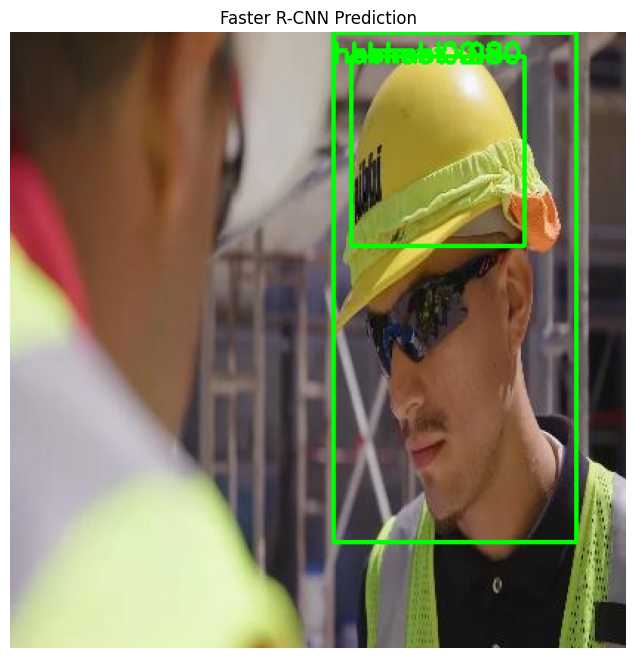

In [ ]:
# =====================
# PREDICT ON TEST IMAGE
# =====================

import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torch

class_names = {
    1: "head",
    2: "helmet",
    3: "person"
}

colors = {
    1: (0, 0, 255),      # head
    2: (0, 255, 0),      # helmet
    3: (255, 0, 0)       # person
}

# Load model
model.load_state_dict(
    torch.load(
        SAVE_PATH,
        map_location=device
    )
)

model.to(device)
model.eval()

# Random test image
idx = random.randint(
    0,
    len(test_dataset) - 1
)

image, _ = test_dataset[idx]

image_pil = T.ToPILImage()(image)

# Prediction
with torch.no_grad():

    prediction = model(
        [image.to(device)]
    )[0]


pred_img = cv2.cvtColor(
    np.array(image_pil),
    cv2.COLOR_RGB2BGR
)

score_threshold = 0.5

for box, label, score in zip(
    prediction["boxes"].cpu().numpy(),
    prediction["labels"].cpu().numpy(),
    prediction["scores"].cpu().numpy()
):

    if score < score_threshold:
        continue

    x1, y1, x2, y2 = map(
        int,
        box
    )

    color = colors.get(
        int(label),
        (255,255,255)
    )

    cv2.rectangle(
        pred_img,
        (x1, y1),
        (x2, y2),
        color,
        2
    )

    text = (
        f"{class_names.get(int(label),'UNK')} "
        f"{score:.2f}"
    )

    cv2.putText(
        pred_img,
        text,
        (x1, max(20, y1 - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2
    )

# Show result
plt.figure(figsize=(10,8))

plt.imshow(
    cv2.cvtColor(
        pred_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Faster R-CNN Prediction"
)

plt.axis("off")
plt.show()

### 9. Lưu mô hình tốt nhất vào Google Drive

In [13]:
# =====================
# SAVE MODEL TO GOOGLE DRIVE
# =====================

import shutil
import os

drive_dir = (
    "/content/drive/MyDrive/"
    "Lab03_FasterRCNN"
)

os.makedirs(
    drive_dir,
    exist_ok=True
)

destination = os.path.join(
    drive_dir,
    "faster_rcnn_best.pth"
)

shutil.copy(
    SAVE_PATH,
    destination
)

print(
    "Model saved successfully!"
)

print(
    f"Saved at: {destination}"
)

Model saved successfully!
Saved at: /content/drive/MyDrive/Lab03_FasterRCNN/faster_rcnn_best.pth


### 10. Nhận xét

Kết quả dự đoán cho thấy mô hình Faster R-CNN có khả năng phát hiện và định vị tương đối chính xác các đối tượng Helmet, Head và Person trên bộ dữ liệu Safety Helmet. Phần lớn các bounding box được đặt đúng vị trí và gán đúng nhãn lớp tương ứng, phản ánh khả năng học đặc trưng hiệu quả của mô hình.

Ưu điểm của Faster R-CNN là khả năng phát hiện đối tượng ổn định nhờ cơ chế Region Proposal Network (RPN), giúp xác định các vùng chứa đối tượng trước khi thực hiện phân loại và hồi quy bounding box. Điều này góp phần nâng cao độ chính xác phát hiện trên các đối tượng xuất hiện rõ ràng trong ảnh.

Tuy nhiên, mô hình vẫn còn một số hạn chế như bỏ sót đối tượng hoặc định vị chưa thật sự chính xác trong các trường hợp đối tượng nhỏ, bị che khuất hoặc xuất hiện trong bối cảnh phức tạp. Ngoài ra, do thuộc nhóm Two-stage Detector nên tốc độ suy luận của Faster R-CNN thường chậm hơn so với các mô hình One-stage như YOLOv8.

Nhìn chung, Faster R-CNN đạt hiệu quả phát hiện đối tượng tương đối tốt trên bộ dữ liệu Safety Helmet và là một mô hình phù hợp để so sánh với YOLOv8 và DETR trong bài toán phát hiện mũ bảo hiểm.